# Proyecto 2 — Deep Q-Learning en Space Invaders

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala
**Nicolás Concuá**

Guatemala, octubre de 2026

Repositorio: <https://github.com/nicoCT04/Deep_Q_Learning>

---

Este notebook documenta el desarrollo completo de un agente de Aprendizaje por
Refuerzo que juega **Space Invaders** (`ALE/SpaceInvaders-v5`). Está organizado
siguiendo la estructura del trabajo escrito:

1. **Análisis del entorno** (definición del problema, observación, acción, recompensa).
2. **Metodología** (algoritmo, arquitectura, exploración, hiperparámetros).
3. **Iteraciones de entrenamiento** (historial de experimentos, curvas).
4. **Evaluación y video** del agente final (política greedy, competencia).
5. **Discusión y conclusiones**.

> El **entrenamiento** se ejecuta en Google Colab con GPU (sección 2). Este
> notebook, corrido localmente, cubre el análisis del entorno (sección 1) y la
> evaluación/grabación del agente final (sección 4). Las secciones de Colab
> incluyen guardado de *checkpoints* en Google Drive como respaldo.

## 0. Configuración e importaciones

Se fijan semillas para reproducibilidad y se resuelven rutas de forma robusta
(el notebook funciona tanto si se corre desde la raíz del repositorio como desde
`notebook/`).

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# --- Reproducibilidad ---
SEED = 42
np.random.seed(SEED)

# --- Rutas robustas: raíz del repo y carpeta de figuras ---
_cwd = os.getcwd()
REPO_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebook" else _cwd
REPORTS_DIR = os.path.join(REPO_ROOT, "reports")
VIDEOS_DIR = os.path.join(REPO_ROOT, "videos")
MODELS_DIR = os.path.join(REPO_ROOT, "models")
NOTEBOOK_DIR = os.path.join(REPO_ROOT, "notebook")
for d in (REPORTS_DIR, VIDEOS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)

# Permite importar ale_utils.py tanto desde la raíz como desde notebook/
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

ENV_ID = "ALE/SpaceInvaders-v5"
print("REPO_ROOT:", REPO_ROOT)
print("gymnasium:", gym.__version__, "| ale_py:", ale_py.__version__)

REPO_ROOT: /Users/nicolasconcua/Documents/UVG/8ctavosemestre/deepLearning/Deep_Q_Learning
gymnasium: 1.3.0 | ale_py: 0.12.1


## 1. Definición del problema y análisis del entorno

Antes de entrenar cualquier agente se analiza el entorno, de forma análoga al EDA
de un problema supervisado.

### 1.1 Descripción de `ALE/SpaceInvaders-v5`

Space Invaders es un juego de Atari 2600 en el que el jugador controla un cañón
que se mueve horizontalmente en la parte inferior de la pantalla y dispara a
oleadas de invasores que descienden progresivamente. El agente interactúa con el
juego a través del **Arcade Learning Environment (ALE)** expuesto como un entorno
de Gymnasium [1, 2].

- **Objetivo**: destruir a todos los invasores acumulando el mayor puntaje
  posible, evitando ser alcanzado por sus disparos y evitando que lleguen al
  fondo de la pantalla.
- **Recompensa**: puntos que otorga el juego al destruir invasores. Los aliens de
  filas superiores valen más, por lo que la recompensa por paso toma valores
  discretos (múltiplos de 5). Es una señal **dispersa**: la mayoría de los pasos
  dan recompensa cero.
- **Vidas**: el agente inicia con **3 vidas**; pierde una cada vez que un disparo
  enemigo lo alcanza. `info["lives"]` reporta las vidas restantes.
- **Fin de episodio**: `terminated = True` cuando se agotan las vidas;
  `truncated = True` cuando se alcanza el tope de `max_num_frames_per_episode`
  (108000 frames ALE ≈ 30 min de juego real).

### 1.2 Configuración por defecto de la versión `-v5`

La variante `-v5` implementa el protocolo de evaluación recomendado por Machado
et al. [3]:

- **`frameskip = 4`**: cada acción del agente se repite durante 4 frames del
  emulador (el entorno ya devuelve el máximo por par de frames para evitar
  parpadeo de sprites).
- **`repeat_action_probability = 0.25`** (*sticky actions*): con probabilidad
  0.25 el emulador repite la acción anterior en lugar de la nueva. Introduce
  estocasticidad para evitar que el agente memorice una secuencia fija de
  acciones.
- **`full_action_space = False`**: se usa el subconjunto **mínimo** de 6 acciones
  específico de Space Invaders (ver 1.4).

Las siguientes celdas confirman empíricamente estos valores.

In [2]:
# --- Inspección del entorno crudo (sin wrappers) ---
env = gym.make(ENV_ID, render_mode="rgb_array")

print("Espacio de observación:", env.observation_space)
print("Espacio de acción     :", env.action_space)
print("Significado de acciones:", env.unwrapped.get_action_meanings())
print("Parámetros de la spec  :", env.spec.kwargs)

obs, info = env.reset(seed=SEED)
print("\nObservación tras reset -> shape:", obs.shape, "dtype:", obs.dtype,
      "rango:", (int(obs.min()), int(obs.max())))
print("info tras reset:", {k: info[k] for k in ('lives', 'frame_number') if k in info})
env.close()

Espacio de observación: Box(0, 255, (210, 160, 3), uint8)
Espacio de acción     : Discrete(6)
Significado de acciones: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
Parámetros de la spec  : {'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_frames_per_episode': 108000, 'render_mode': 'rgb_array'}

Observación tras reset -> shape: (210, 160, 3) dtype: uint8 rango: (0, 181)
info tras reset: {'lives': 3, 'frame_number': 0}


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


### 1.3 Espacio de observación y preprocesamiento

La observación cruda es una imagen **RGB de 210×160×3** en `uint8`. Alimentar la
red con esta imagen a color y a plena resolución es costoso e innecesario: el
color aporta poca información en Space Invaders y la resolución completa infla el
número de parámetros. Se aplica el preprocesamiento estándar de la literatura de
DQN [1]:

1. **Escala de grises** (de 3 canales a 1).
2. **Redimensionado a 84×84**.
3. **Apilado de 4 frames** consecutivos (*frame stacking*), para que la
   observación contenga información temporal (velocidad y dirección de disparos e
   invasores), ya que un solo frame no basta para inferir movimiento.
4. **Normalización** de los píxeles a [0, 1] dentro de la red.

La figura siguiente compara un frame RGB crudo con su versión preprocesada
(gris, 84×84).

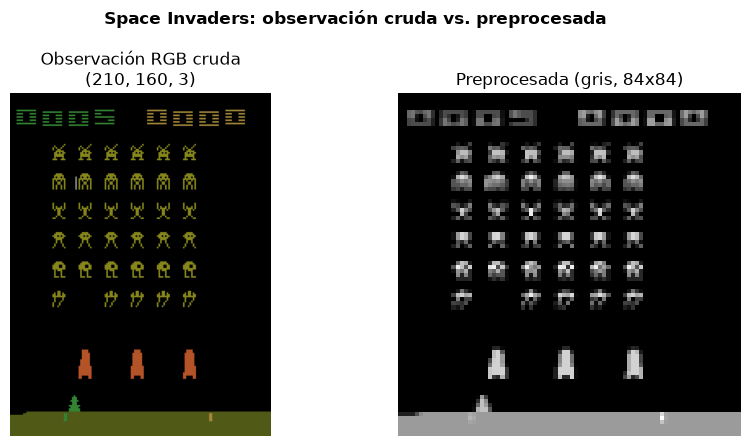

In [3]:
import cv2

def preprocesar_frame(frame_rgb, tam=84):
    """Escala de grises + redimensionado a tam x tam, como en DQN [1]."""
    gris = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
    peq = cv2.resize(gris, (tam, tam), interpolation=cv2.INTER_AREA)
    return peq

# Tomar un frame representativo (unos pasos dentro de la partida)
env = gym.make(ENV_ID, render_mode="rgb_array")
env.reset(seed=SEED)
for _ in range(60):
    frame, _, term, trunc, _ = env.step(env.action_space.sample())
    if term or trunc:
        env.reset(seed=SEED)
env.close()

frame_prep = preprocesar_frame(frame)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(frame)
axes[0].set_title(f"Observación RGB cruda\n{frame.shape}")
axes[0].axis("off")
axes[1].imshow(frame_prep, cmap="gray")
axes[1].set_title(f"Preprocesada (gris, {frame_prep.shape[0]}x{frame_prep.shape[1]})")
axes[1].axis("off")
fig.suptitle("Space Invaders: observación cruda vs. preprocesada", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "observacion_rgb_vs_preprocesada.png"),
            dpi=130, bbox_inches="tight")
plt.show()

### 1.4 Espacio de acción

El espacio de acción es `Discrete(6)`; el subconjunto mínimo de Space Invaders:

| Acción | Nombre | Efecto |
|:------:|:-------|:-------|
| 0 | `NOOP` | No hacer nada |
| 1 | `FIRE` | Disparar |
| 2 | `RIGHT` | Moverse a la derecha |
| 3 | `LEFT` | Moverse a la izquierda |
| 4 | `RIGHTFIRE` | Moverse a la derecha y disparar |
| 5 | `LEFTFIRE` | Moverse a la izquierda y disparar |

Se usa este subconjunto de 6 acciones (`full_action_space = False`) en lugar de
las 18 acciones genéricas de Atari: reduce el espacio de salida de la red y acota
la exploración a acciones con sentido en el juego, acelerando el aprendizaje sin
perder capacidad expresiva.

### 1.5 Análisis de la señal de recompensa

Se ejecuta un episodio con acciones aleatorias para caracterizar la recompensa:
su magnitud, su frecuencia (densa vs. dispersa) y la acumulación a lo largo del
tiempo. Esto motiva las decisiones de preprocesamiento de la recompensa.

In [4]:
env = gym.make(ENV_ID, render_mode="rgb_array")
obs, info = env.reset(seed=SEED)
recompensas, retorno_acumulado = [], []
acc = 0.0
term = trunc = False
while not (term or trunc):
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    recompensas.append(float(r))
    acc += float(r)
    retorno_acumulado.append(acc)
env.close()

recompensas = np.array(recompensas)
no_cero = recompensas[recompensas != 0]
print("Pasos del episodio (aleatorio):", len(recompensas))
print("Retorno total:", recompensas.sum())
print("Valores de recompensa distintos:", sorted(set(recompensas.tolist())))
print(f"Fracción de pasos con recompensa != 0: {(recompensas != 0).mean():.3%}")
print("Recompensa media por paso:", round(recompensas.mean(), 4))

Pasos del episodio (aleatorio): 622
Retorno total: 210.0
Valores de recompensa distintos: [0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
Fracción de pasos con recompensa != 0: 1.929%
Recompensa media por paso: 0.3376


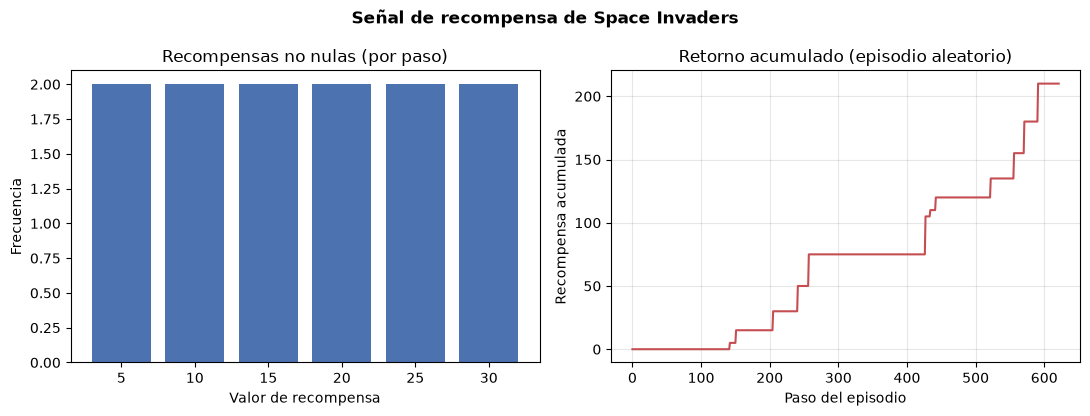

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) Distribución de las recompensas no nulas
vals, cuentas = np.unique(no_cero, return_counts=True)
axes[0].bar([str(int(v)) for v in vals], cuentas, color="#4C72B0")
axes[0].set_title("Recompensas no nulas (por paso)")
axes[0].set_xlabel("Valor de recompensa")
axes[0].set_ylabel("Frecuencia")

# (b) Retorno acumulado a lo largo del episodio
axes[1].plot(retorno_acumulado, color="#C44E52")
axes[1].set_title("Retorno acumulado (episodio aleatorio)")
axes[1].set_xlabel("Paso del episodio")
axes[1].set_ylabel("Recompensa acumulada")
axes[1].grid(alpha=0.3)

fig.suptitle("Señal de recompensa de Space Invaders", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, "analisis_recompensa.png"),
            dpi=130, bbox_inches="tight")
plt.show()

**Observaciones sobre la recompensa:**

- Es **dispersa**: solo una pequeña fracción de los pasos recibe recompensa
  distinta de cero (el resto son ceros mientras el agente se mueve o falla).
- Toma **valores discretos de distinta magnitud** (múltiplos de 5, según la fila
  del invasor destruido). Esta heterogeneidad puede desestabilizar el
  entrenamiento de los valores Q.
- **Decisión de diseño — *reward clipping*:** se recorta la recompensa a su signo
  (`{-1, 0, +1}`), técnica estándar de DQN [1]. Homogeniza la escala entre juegos
  y estabiliza el gradiente. Como consecuencia, la señal que optimiza el agente
  es "¿acerté un disparo?" y no "¿cuántos puntos exactos gané?"; el puntaje real
  (sin recortar) se mide aparte en la evaluación, que es la métrica de la
  competencia.
- **No se aplica *reward shaping*** adicional: la recompensa nativa del juego ya
  está alineada con el objetivo (destruir invasores = sobrevivir y puntuar).

### 1.6 Decisiones de diseño derivadas del análisis

Resumen de las decisiones que se arrastran a la fase de entrenamiento:

| Aspecto | Decisión | Justificación |
|:--------|:---------|:--------------|
| Observación | Gris 84×84, stack de 4 frames | Reduce dimensionalidad; captura movimiento [1] |
| Acciones | Subconjunto mínimo (6) | Exploración más eficiente que las 18 genéricas |
| Recompensa | *Reward clipping* a {-1,0,+1} | Estabiliza el aprendizaje de Q [1] |
| Manejo de vidas | *Episodic life* en entrenamiento | Cada vida perdida termina el "episodio" de entrenamiento → señal de fin más frecuente; en evaluación se juega el episodio completo (3 vidas) |
| Estocasticidad | Se conservan *sticky actions* (0.25) y `frameskip=4` | Protocolo de evaluación estándar [3]; evita sobreajuste a secuencias fijas |
| Frame skip | 4 (por defecto de `-v5`) | Menos pasos de decisión por segundo de juego → entrenamiento más rápido |

Estos wrappers se implementan en la fase de entrenamiento mediante el
`AtariWrapper` de Stable-Baselines3 más el apilado de frames, garantizando que el
**mismo preprocesamiento** se use en entrenamiento y evaluación (requisito de la
competencia).

## Referencias

[1] V. Mnih et al., "Human-level control through deep reinforcement learning",
*Nature*, vol. 518, pp. 529–533, 2015.

[2] Farama Foundation, "Gymnasium & Arcade Learning Environment (ALE)
documentation", 2024. <https://gymnasium.farama.org/environments/atari/>

[3] M. C. Machado et al., "Revisiting the Arcade Learning Environment: Evaluation
Protocols and Open Problems for General Agents", *JAIR*, vol. 61, 2018.

[4] A. Raffin et al., "Stable-Baselines3: Reliable Reinforcement Learning
Implementations", *JMLR*, vol. 22, 2021.

[5] H. van Hasselt, A. Guez, D. Silver, "Deep Reinforcement Learning with Double
Q-learning", *AAAI*, 2016.

---

*Las secciones 2 (metodología y entrenamiento en Colab), 3 (iteraciones), 4
(evaluación y video) y 5 (discusión y conclusiones) se agregan en las siguientes
fases del proyecto.*